In [16]:
import pandas as pd 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , precision_score  , recall_score , f1_score , confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt 
import shap  ## it will give explanation why xgboost predicted this prediction for this patient 



df = pd.read_csv("D:/AYUVA/ml/data/processed/cardio_clean3.csv")



features = ['age_year', 'ap_hi', 'ap_lo', 
            'cholesterol', 'gluc', 'smoke', 'alco', 'active','bmi','pulse_pressure','map']

target = "cardio"

x = df[features]
y = df[target]

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2,random_state = 42 , stratify= y )
#we dont need scaling for xgboost

In [2]:
model = XGBClassifier()
train_fit = model.fit(x_train,y_train)
x_test_predict = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, x_test_predict))
print("Precision:", precision_score(y_test, x_test_predict))
print("Recall:", recall_score(y_test, x_test_predict))
print("F1:", f1_score(y_test, x_test_predict))
print("Confusion Matrix:\n", confusion_matrix(y_test, x_test_predict))

Accuracy: 0.7292142857142857
Precision: 0.7473375520913721
Recall: 0.6921097770154374
F1: 0.7186641929499072
Confusion Matrix:
 [[5367 1637]
 [2154 4842]]


In [3]:
param_grid = {
    'n_estimators' : [100,200,300],
    'max_depth' : [3,5,7],
    'learning_rate': [0.01,0.1,0.2,0.3],
    'subsample':[0.6,0.7,0.8,1.0]              #every tree will we trained of 80% of random data means each tree is differently trained 
}

grid_search = GridSearchCV(
    XGBClassifier(),
    param_grid,
    cv = 3 ,                                  #3-fold-cross validation
    scoring = 'recall',                          #priority -- recall 
    n_jobs = -1                                   #use all cores 
)

grid_search.fit(x_train,y_train)
print("Best params:", grid_search.best_params_)
print("Best CV recall:", grid_search.best_score_)


Best params: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV recall: 0.7001750314765784


In [4]:
best_model = XGBClassifier(**grid_search.best_params_)
best_model.fit(x_train,y_train)
final_predict = best_model.predict(x_test)


print("Final Accuracy:", accuracy_score(y_test, final_predict))
print("Final Precision:", precision_score(y_test, final_predict))
print("Final Recall:", recall_score(y_test, final_predict))
print("Final F1:", f1_score(y_test, final_predict))
print("Confusion Matrix:\n", confusion_matrix(y_test, final_predict))

Final Accuracy: 0.7336428571428572
Final Precision: 0.7511917576503152
Final Recall: 0.698256146369354
Final F1: 0.7237573153566931
Confusion Matrix:
 [[5386 1618]
 [2111 4885]]


In [ ]:
print("x_test shape:", x_test.shape)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(x_test)
print("shap_values shape:", shap_values.shape)
row =x_test.iloc[[0]]
print(row)
print("\nModel's prediction for this person:", best_model.predict(row)[0])

for feature, value in zip(x_test.columns, shap_values[0]):   #zip takes two list and pair them item by item like first item with first 
    print(f"{feature}: {value:.4f}")

x_test shape: (14000, 11)
shap_values shape: (14000, 11)
        age_year  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  active  \
18682  53.075975    120     85            1     1      0     0       1   

             bmi  pulse_pressure        map  
18682  24.765869              35  96.666667  

Model's prediction for this person: 0
age_year: -0.1326
ap_hi: -0.5722
ap_lo: 0.0597
cholesterol: -0.1474
gluc: 0.0158
smoke: 0.0183
alco: 0.0101
active: -0.0491
bmi: -0.0491
pulse_pressure: -0.0565
map: -0.1507


In [14]:
predictions = best_model.predict(x_test)
high_risk_indices = [i for i, p in enumerate(predictions) if p == 1]
idx = high_risk_indices[0]   # first high-risk person in the test set

row = x_test.iloc[[idx]]
print("This person's data:")
print(row)

print("\nModel's prediction:", best_model.predict(row)[0])

print("\nSHAP values for this person:")
for feature, value in zip(x_test.columns, shap_values[idx]):
    print(f"{feature}: {value:.4f}")

This person's data:
        age_year  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  active  \
40992  57.716632    130     90            1     1      0     0       1   

             bmi  pulse_pressure         map  
40992  23.046875              40  103.333333  

Model's prediction: 1

SHAP values for this person:
age_year: 0.0806
ap_hi: 0.0812
ap_lo: 0.1240
cholesterol: -0.1504
gluc: 0.0203
smoke: 0.0287
alco: 0.0148
active: -0.0423
bmi: -0.1308
pulse_pressure: -0.0131
map: 0.2553


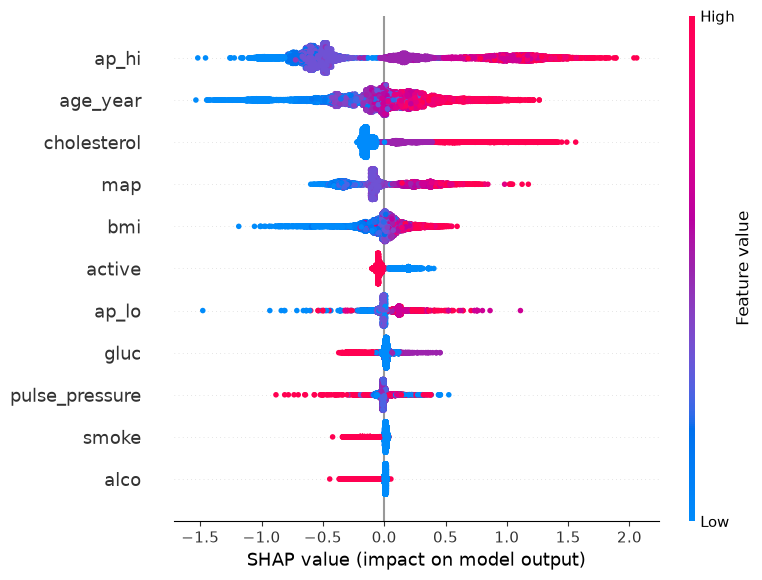

In [24]:
shap.summary_plot(shap_values , x_test,show=False)
plt.tight_layout()
plt.savefig('D:/AYUVA/docs/shap_summary.png', dpi=150)

plt.show()

In [25]:
import joblib 

joblib.dump(best_model,'D:/AYUVA/ml/models/cardio_risk_model.pkl')

['D:/AYUVA/ml/models/cardio_risk_model.pkl']

In [26]:
import json 
feature_order = ['age_year', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'pulse_pressure', 'map']

with open('D:/AYUVA/ml/models/feature_order.json','w') as f :
    json.dump(feature_order,f)
